# Matching biosignals to mathematical series

`biotuner.math_series` asks a simple question: **which classic mathematical
sequence — Fibonacci, Lucas, harmonics, Farey, … — is most present in a
biosignal's peak-ratio structure?** It takes a fitted `compute_biotuner`
object (or a `HarmonicInput`), compares its peak ratios (or *extended*-peak
ratios) against the ratios generated by each series, and reports the match
proportions. The matched subset of the winning series can then be turned into
a scale or a consonance-selected mode.

This notebook walks through the full workflow on a real EEG recording.


## 1. Extract peaks and ratios from the EEG

We load an example recording (104 channels × 4000 samples @ 1000 Hz), pick one
channel, and extract its spectral **peaks** and the harmonically **extended**
peaks. Both yield octave-reduced peak ratios in `[1, 2)` — the input the
matcher works on.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from biotuner.biotuner_object import compute_biotuner

data = np.load("../data/EEG_example.npy")   # (104 channels, 4000 samples)
sf = 1000

bt = compute_biotuner(sf=sf, peaks_function="FOOOF", precision=0.5)
bt.peaks_extraction(data[0], min_freq=2, max_freq=40, n_peaks=6)
bt.peaks_extension(n_harm=5)

print("peaks (Hz):          ", np.round(bt.peaks, 2))
print("peak ratios:         ", [round(r, 3) for r in bt.peaks_ratios])
print("n extended ratios:   ", len(bt.extended_peaks_ratios))

peaks (Hz):           [10.42 20.41 25.76 23.05 29.7   7.82]
peak ratios:          [1.106, 1.118, 1.129, 1.153, 1.236, 1.262, 1.289, 1.305, 1.332, 1.425, 1.455, 1.474, 1.647, 1.899, 1.959]
n extended ratios:    21


## 2. Which mathematical series is present?

Feed the fitted object to `math_series`. `analyze()` scores every series; the
`summary()` table ranks them by the proportion of the EEG's peak ratios each
one reproduces.

In [2]:
from biotuner.math_series import math_series

ms = math_series(bt, ratios_source="peaks_ratios", maxdenom=24).analyze()
print("Best-matching series:", ms.best_series, "\n")
print(ms.summary())

Best-matching series: lucas 

      series  proportion  ...  n_target  n_series_ratios
0      lucas    0.866667  ...        15              120
1  harmonics    0.666667  ...        15               83
2  fibonacci    0.600000  ...        15               87
3      farey    0.533333  ...        15               64

[4 rows x 6 columns]


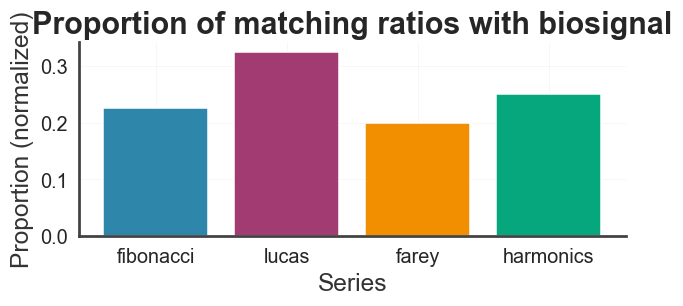

In [3]:
ms.plot_proportions();

### Peaks vs. extended peaks

`ratios_source` switches between the raw spectral peak ratios and the
harmonically extended ones — they can favour different series.

peaks    -> best: lucas
extended -> best: lucas


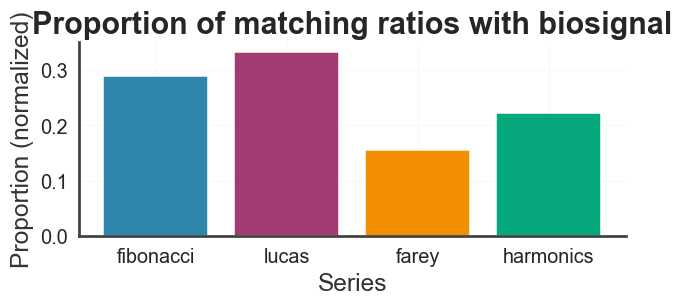

In [4]:
ms_ext = math_series(bt, ratios_source="extended_peaks_ratios", maxdenom=24).analyze()
print("peaks    -> best:", ms.best_series)
print("extended -> best:", ms_ext.best_series)
ms_ext.plot_proportions();

### Where do the peaks sit? — the ratio-pairs scatter

Each small dot is a pair of series elements; the large dots are the pairs whose
ratio matches one of the EEG's peak ratios.

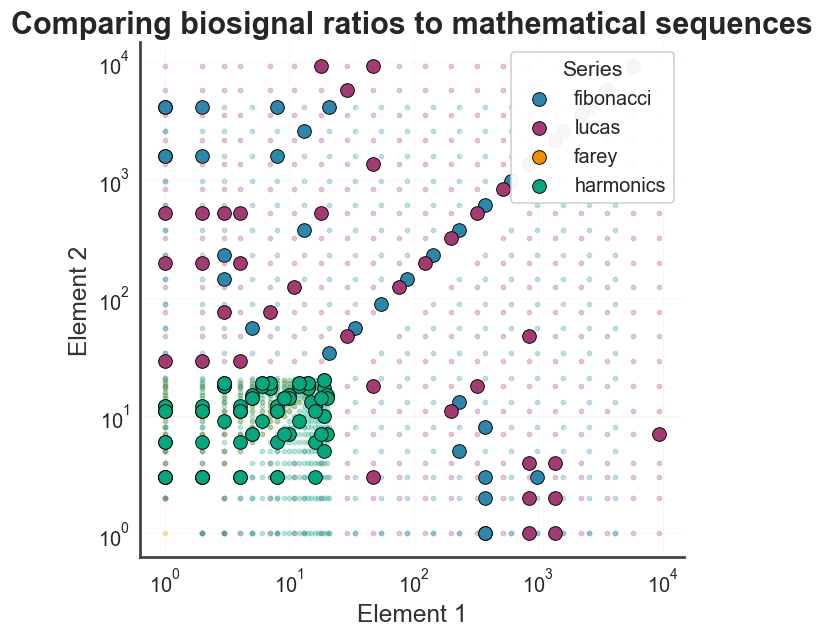

In [5]:
ms.plot_ratio_pairs();

## 3. Across the whole montage

Running the matcher on every channel answers the population question: which
series dominates this recording's peak-ratio structure?

Best series per channel: {'fibonacci': 19, 'lucas': 78, 'farey': 0, 'harmonics': 6}


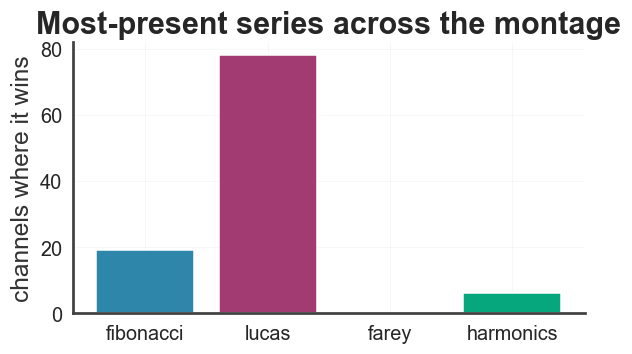

In [6]:
best_counts = {s: 0 for s in ms.series_names}
for ch in range(data.shape[0]):
    try:
        bt_ch = compute_biotuner(sf=sf, peaks_function="FOOOF", precision=0.5)
        bt_ch.peaks_extraction(data[ch], min_freq=2, max_freq=40, n_peaks=6)
        m = math_series(bt_ch, ratios_source="peaks_ratios", maxdenom=24).analyze()
        best_counts[m.best_series] += 1
    except Exception:
        continue

print("Best series per channel:", best_counts)

from biotuner.plot_config import set_biotuner_style, get_color_palette
set_biotuner_style()
plt.figure(figsize=(6, 3.2))
plt.bar(list(best_counts), list(best_counts.values()),
        color=get_color_palette("biotuner_gradient", len(best_counts)))
plt.ylabel("channels where it wins")
plt.title("Most-present series across the montage");

## 4. Derive musical structures

The matched subset of the winning series is a scale; `series_mode` reduces it
to a consonance-selected mode.

In [7]:
print("Scale from best series:", [round(x, 3) for x in ms.series_scale()])
print("7-note mode (pairwise):", [round(x, 3) for x in ms.series_mode(n_steps=7, method="pairwise")])
print("Scale in cents:        ", [round(c, 1) for c in ms.scale_cents()])

Scale from best series: [1.0, 1.103, 1.103, 1.106, 1.118, 1.121, 1.131, 1.234, 1.236, 1.236, 1.236, 1.236, 1.236, 1.236, 1.236, 1.236, 1.263, 1.285, 1.286, 1.286, 1.287, 1.304, 1.306, 1.332, 1.333, 1.431, 1.455, 1.474, 1.474, 1.646, 1.958, 1.965, 1.972]
7-note mode (pairwise): [1.236, 1.236, 1.236, 1.286, 1.287, 1.474, 1.474]
Scale in cents:         [0.0, 169.2, 170.4, 173.7, 193.2, 197.8, 212.6, 364.1, 366.5, 366.8, 366.9, 366.9, 366.9, 366.9, 366.9, 367.1, 404.4, 434.0, 435.1, 436.1, 436.8, 459.9, 461.6, 496.4, 498.0, 620.3, 648.7, 671.3, 671.8, 863.3, 1163.6, 1169.8, 1175.2]


## 5. Creative views — where the extended peaks sit among the series

These figures put the EEG's **extended**-peak ratios next to each series' ratio
lattice. First a few shared helpers (colours, a cents helper, each series'
ratio set, and which series ratios the EEG matched).

In [8]:
from biotuner.math_series import series_ratio_pairs
from biotuner.biotuner_utils import ratio2frac
from biotuner.plot_config import get_color_palette

SERIES = ms.series_names
COLORS = dict(zip(SERIES, get_color_palette("biotuner_gradient", len(SERIES))))
MAXDENOM, ORDER = 24, 13

def cents(r):
    return 1200 * np.log2(np.asarray(r, float))

def series_ratios(name, order=ORDER):
    return np.array(sorted({round(x, 5) for x, _ in series_ratio_pairs(name, order)}))

# EEG extended-peak ratios and which series ratios they matched
ms_ext = math_series(bt, ratios_source="extended_peaks_ratios", maxdenom=MAXDENOM).analyze()
brain_ext = np.array(sorted(set(np.round(bt.extended_peaks_ratios, 5))))
matched = {n: {round(r, 5) for r, _ in ms_ext.series_scores[n]["matched_series_pairs"]}
           for n in SERIES}
print("EEG extended-peak ratios (cents):", [int(c) for c in cents(brain_ext)])

EEG extended-peak ratios (cents): [84, 180, 196, 211, 241, 330, 372, 400, 440, 454, 493, 532, 619, 655, 666, 701, 736, 866, 1111, 1165, 1200]


### Octave wheel

The octave wrapped onto a circle (angle = cents); each series is a ring of
ratio-ticks, the EEG extended peaks are the black spokes, and a filled dot
marks a match.

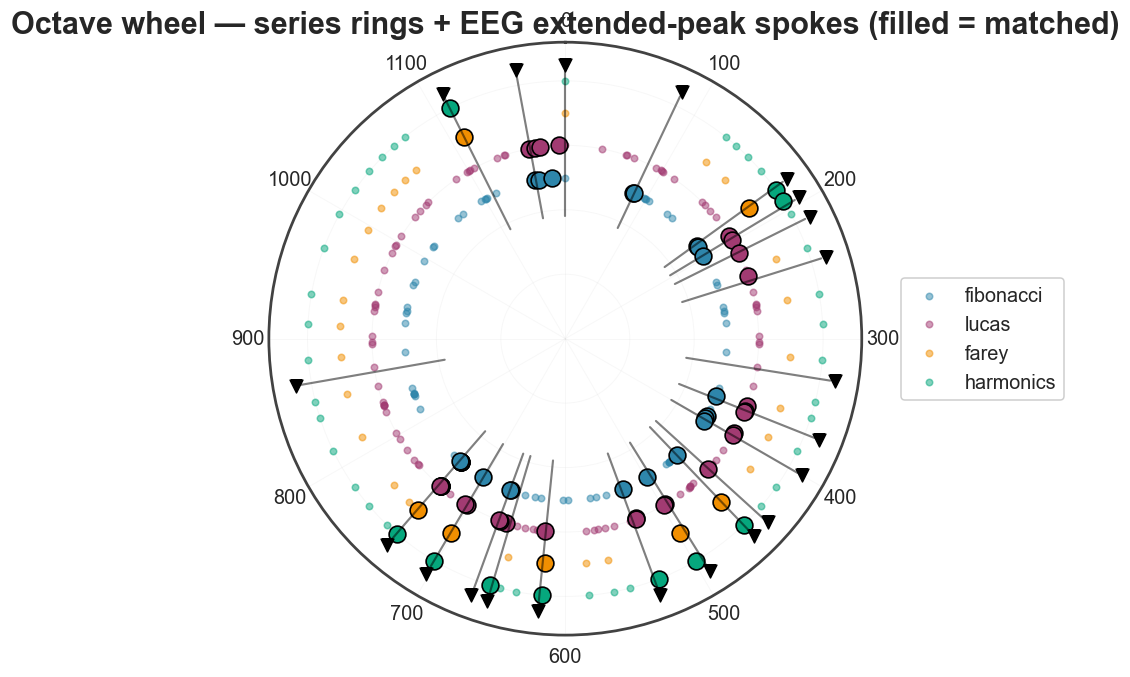

In [9]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection="polar")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
for name, rr in zip(SERIES, np.linspace(1.25, 2.0, len(SERIES))):
    rats = series_ratios(name)
    ax.scatter(2*np.pi*np.log2(rats), [rr]*len(rats), s=18, color=COLORS[name], alpha=0.5, label=name)
    if matched[name]:
        mt = 2*np.pi*np.log2(sorted(matched[name]))
        ax.scatter(mt, [rr]*len(mt), s=120, color=COLORS[name], edgecolor="k", linewidth=1.1)
for r in brain_ext:
    ax.plot([2*np.pi*np.log2(r)]*2, [0.95, 2.08], color="k", lw=1.4, alpha=0.5)
ax.scatter(2*np.pi*np.log2(brain_ext), [2.12]*len(brain_ext), marker="v", color="k", s=70)
ax.set_ylim(0, 2.3); ax.set_yticklabels([])
ax.set_xticks(np.linspace(0, 2*np.pi, 13)[:-1]); ax.set_xticklabels(range(0, 1200, 100))
ax.set_title("Octave wheel — series rings + EEG extended-peak spokes (filled = matched)")
ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5));

### Cents ruler — the ratio lattice

Each series as a lane of ratio-ticks on a 0–1200 cents axis (bold = matched);
guide lines drop from each EEG extended peak.

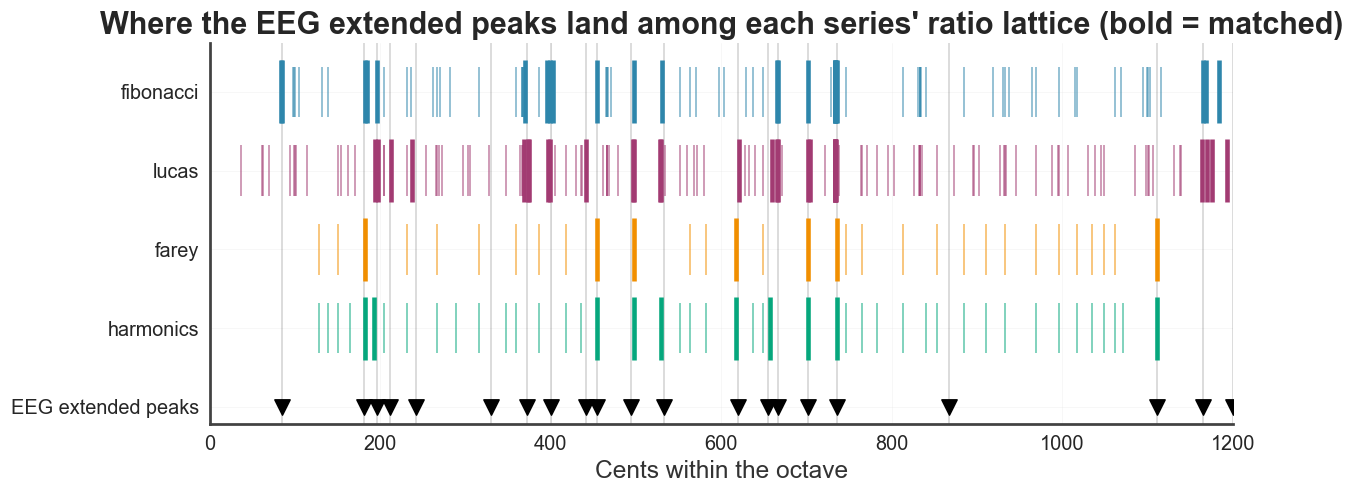

In [10]:
fig, ax = plt.subplots(figsize=(12, 4.5))
for c in cents(brain_ext):
    ax.axvline(c, color="k", lw=1, alpha=0.18)
for i, name in enumerate(SERIES):
    y = len(SERIES) - i
    ax.vlines(cents(series_ratios(name)), y - 0.32, y + 0.32, color=COLORS[name], lw=1.3, alpha=0.5)
    if matched[name]:
        ax.vlines(cents(sorted(matched[name])), y - 0.4, y + 0.4, color=COLORS[name], lw=3)
ax.scatter(cents(brain_ext), [0]*len(brain_ext), marker="v", s=100, color="k")
ax.set_yticks(range(len(SERIES) + 1))
ax.set_yticklabels(["EEG extended peaks"] + SERIES[::-1])
ax.set_xlim(0, 1200); ax.set_xlabel("Cents within the octave")
ax.set_title("Where the EEG extended peaks land among each series' ratio lattice (bold = matched)");

### How tightly each series fits

For every extended peak, the cents distance to the *nearest* ratio of each
series (lower = closer). A continuous, density-aware view of the match —
note Farey is dense yet does not fit tightest, so this is not just a density
effect.

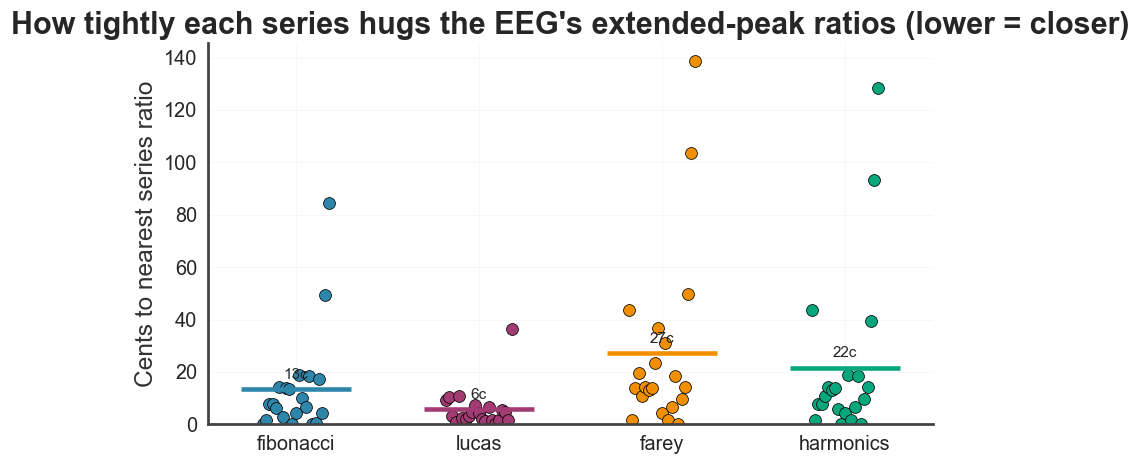

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ext_c = cents(brain_ext)
jit = np.linspace(-0.18, 0.18, len(ext_c))
for i, name in enumerate(SERIES):
    sc = cents(series_ratios(name))
    nearest = np.array([np.min(np.abs(sc - c)) for c in ext_c])
    ax.scatter(np.full(len(nearest), i) + jit, nearest, s=60, color=COLORS[name], edgecolor="k", linewidth=0.5)
    ax.hlines(nearest.mean(), i - 0.3, i + 0.3, color=COLORS[name], lw=3)
    ax.text(i, nearest.mean() + 4, f"{nearest.mean():.0f}c", ha="center", fontsize=10)
ax.set_xticks(range(len(SERIES))); ax.set_xticklabels(SERIES)
ax.set_ylabel("Cents to nearest series ratio"); ax.set_ylim(bottom=0)
ax.set_title("How tightly each series hugs the EEG's extended-peak ratios (lower = closer)");

### Simplicity bubbles

Each series ratio is a bubble sized by simplicity (bigger = simpler fraction,
i.e. smaller denominator). Do the EEG peaks land on the simple rungs? Outlined
bubbles are matched.

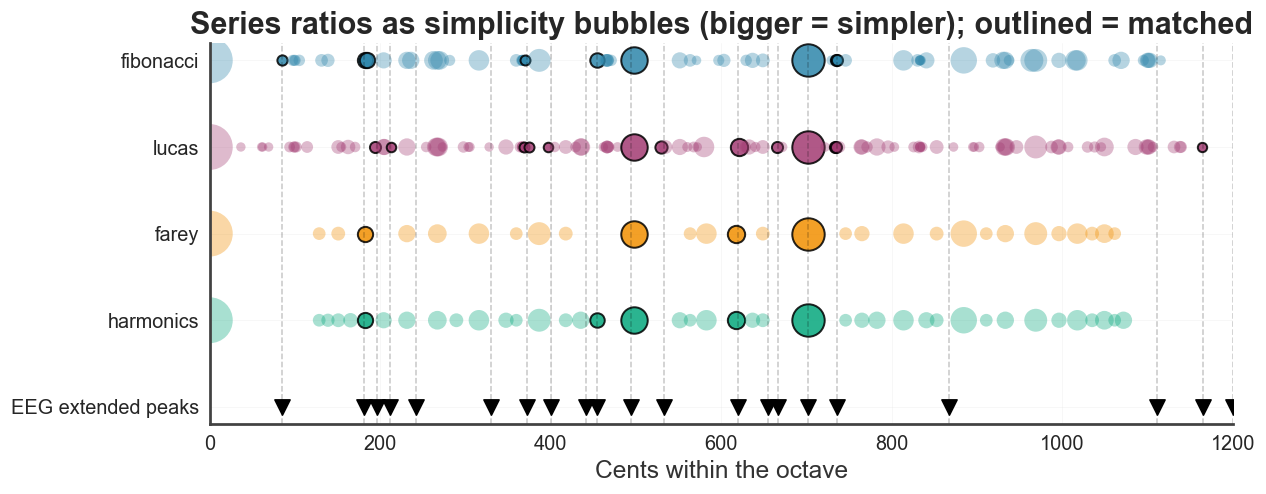

In [12]:
fig, ax = plt.subplots(figsize=(12, 4.5))
for c in cents(brain_ext):
    ax.axvline(c, color="k", lw=1, ls="--", alpha=0.22)
for i, name in enumerate(SERIES):
    y = len(SERIES) - i
    for r in series_ratios(name):
        _, q = ratio2frac(r, MAXDENOM)
        hit = round(r, 5) in matched[name]
        ax.scatter(float(cents(r)), y, s=900 / q, color=COLORS[name],
                   alpha=0.85 if hit else 0.35,
                   edgecolor="k" if hit else "none", linewidth=1.3 if hit else 0)
ax.scatter(cents(brain_ext), [0]*len(brain_ext), marker="v", s=100, color="k")
ax.set_yticks(range(len(SERIES) + 1))
ax.set_yticklabels(["EEG extended peaks"] + SERIES[::-1])
ax.set_xlim(0, 1200); ax.set_xlabel("Cents within the octave")
ax.set_title("Series ratios as simplicity bubbles (bigger = simpler); outlined = matched");

## 6. Effect of `order` on matching

`order` sets how many terms each series generates — more terms means a denser
ratio set, which trivially matches more peaks. So the absolute proportions rise
with `order` and then saturate. The practical lesson: **keep `order` fixed when
comparing series** — only proportions computed at the same `order` (and
`maxdenom`) are comparable. The *ranking* is usually far more stable than the
absolute values.

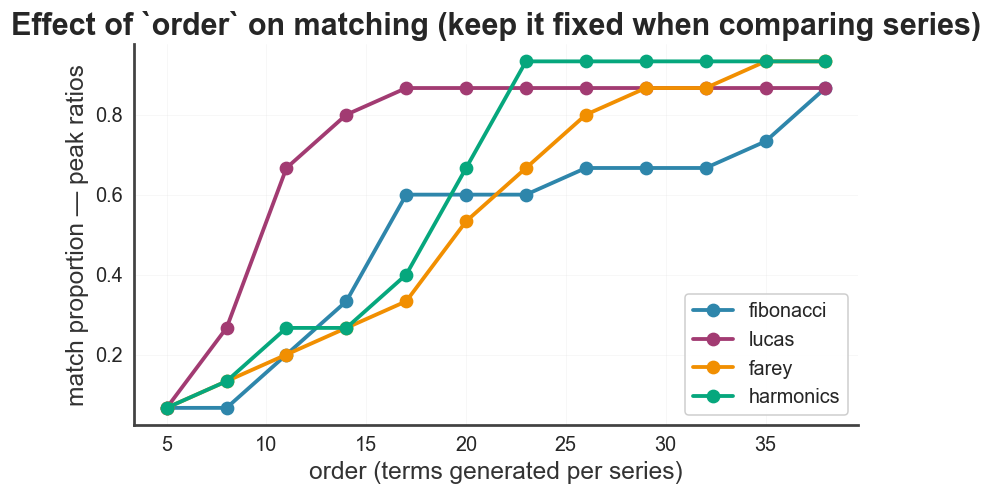

In [13]:
orders = list(range(5, 41, 3))
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for name in SERIES:
    props = [math_series(bt, ratios_source="peaks_ratios", order=o, maxdenom=MAXDENOM)
             .analyze().series_scores[name]["proportion"] for o in orders]
    ax.plot(orders, props, "-o", color=COLORS[name], label=name)
ax.set_xlabel("order (terms generated per series)")
ax.set_ylabel("match proportion — peak ratios")
ax.set_title("Effect of `order` on matching (keep it fixed when comparing series)")
ax.legend();

## 7. Parameters to control

| Parameter | Default | Controls |
|---|---|---|
| `ratios_source` | `"peaks_ratios"` | Which EEG ratios to analyse: raw peaks vs `"extended_peaks_ratios"`. |
| `maxdenom` | `24` | **Matching strictness.** Ratios match if their `limit_denominator(maxdenom)` fractions agree. Lower (≈12–16) = lenient, higher (≈40–60) = strict. Useful range ≈16–48. |
| `series_names` | `["fibonacci", "lucas", "farey", "harmonics"]` | Which series to compare (also available: `padovan, pell, jacobsthal, mersenne, hofstadter_q, subharmonics, triangular`). |
| `order` | `20` | Terms generated per series (Farey order for `farey`); higher = denser. Keep fixed when comparing signals. |
| `octave` | `2.0` | Period the ratios fold into. |

`series_mode()` adds `n_steps`, `method` (`"subset"` exhaustive vs `"pairwise"` greedy) and `function` (consonance metric).

**Rule of thumb:** the two dials you'll actually turn are `ratios_source`
(peaks vs extended) and `maxdenom` (how forgiving the match is). Keep `order`
and `maxdenom` fixed across signals when comparing series — proportions are
only comparable under the same settings.

One more view — each series as an across-octave frequency *comb*, with the EEG
peaks snapped onto the nearest step — is in
`scripts/math_series_series_canvas.py`; see the `biotuner.math_series` API page
for the full reference.
